# Built-in function, funksiya bilan va usiz klib va autoclean orqali proyekt tabulate orqali taqqoslash 

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv('big_mart_sales.csv')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [10]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [11]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [12]:
df.nunique()

Item_Identifier              1559
Item_Weight                   415
Item_Fat_Content                5
Item_Visibility              7880
Item_Type                      16
Item_MRP                     5938
Outlet_Identifier              10
Outlet_Establishment_Year       9
Outlet_Size                     3
Outlet_Location_Type            3
Outlet_Type                     4
Item_Outlet_Sales            3493
dtype: int64

In [ ]:
# Outlet_Establishment_Year ni transformatsiya qilish bu modelga yaxshiroq signal berar ekan
df['Outlet_Age'] = 2026 - df['Outlet_Establishment_Year']
df.drop('Outlet_Establishment_Year', axis=1, inplace=True)  # bu buni drop qilamiz, sababi malumotlar takrorlanmasligi uchun

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Item_Identifier       8523 non-null   str    
 1   Item_Weight           7060 non-null   float64
 2   Item_Fat_Content      8523 non-null   str    
 3   Item_Visibility       8523 non-null   float64
 4   Item_Type             8523 non-null   str    
 5   Item_MRP              8523 non-null   float64
 6   Outlet_Identifier     8523 non-null   str    
 7   Outlet_Size           6113 non-null   str    
 8   Outlet_Location_Type  8523 non-null   str    
 9   Outlet_Type           8523 non-null   str    
 10  Item_Outlet_Sales     8523 non-null   float64
 11  Outlet_Age            8523 non-null   int64  
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


# Handling Missing Values


In [23]:
def tozala(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == 'str':
                df[col] = df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                df[col] = df[col].fillna(df[col].mean(), inplace=True)
    return df
tozala(df)

/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_1437/3475946427.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col] = df[col].fillna(df[col].mean(), inplace=True)
/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_1437/3475946427.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,27
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,17
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,27
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,Medium,Tier 3,Grocery Store,732.3800,28
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,39
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,High,Tier 3,Supermarket Type1,2778.3834,39
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,Medium,Tier 2,Supermarket Type1,549.2850,24
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,Small,Tier 2,Supermarket Type1,1193.1136,22
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,Medium,Tier 3,Supermarket Type2,1845.5976,17


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Item_Identifier       8523 non-null   str    
 1   Item_Weight           8523 non-null   float64
 2   Item_Fat_Content      8523 non-null   str    
 3   Item_Visibility       8523 non-null   float64
 4   Item_Type             8523 non-null   str    
 5   Item_MRP              8523 non-null   float64
 6   Outlet_Identifier     8523 non-null   str    
 7   Outlet_Size           8523 non-null   str    
 8   Outlet_Location_Type  8523 non-null   str    
 9   Outlet_Type           8523 non-null   str    
 10  Item_Outlet_Sales     8523 non-null   float64
 11  Outlet_Age            8523 non-null   int64  
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


# Encoding process

In [25]:
from sklearn.preprocessing import LabelEncoder

def encoding(df):
    le = LabelEncoder()
    for col in df.columns:
        if df[col].dtype == 'str':
            df[col] = le.fit_transform(df[col])  # Encodingda inplace=True  parametri mavjud emas
    return df
df = encoding(df)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Item_Identifier       8523 non-null   int64  
 1   Item_Weight           8523 non-null   float64
 2   Item_Fat_Content      8523 non-null   int64  
 3   Item_Visibility       8523 non-null   float64
 4   Item_Type             8523 non-null   int64  
 5   Item_MRP              8523 non-null   float64
 6   Outlet_Identifier     8523 non-null   int64  
 7   Outlet_Size           8523 non-null   int64  
 8   Outlet_Location_Type  8523 non-null   int64  
 9   Outlet_Type           8523 non-null   int64  
 10  Item_Outlet_Sales     8523 non-null   float64
 11  Outlet_Age            8523 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 799.2 KB


# Aloqadorligini tekshirish 

In [33]:
# Classification uchun
corr_matrix = df.corr()
corr_matrix['Outlet_Size'].sort_values(ascending=False)

Outlet_Size             1.000000
Outlet_Identifier       0.504603
Item_Visibility         0.069309
Item_MRP                0.006059
Item_Identifier         0.001389
Item_Type              -0.001859
Item_Weight            -0.007225
Item_Fat_Content       -0.012058
Item_Outlet_Sales      -0.086182
Outlet_Age             -0.193389
Outlet_Type            -0.201483
Outlet_Location_Type   -0.614311
Name: Outlet_Size, dtype: float64

In [34]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,156,9.30,1,0.016047,4,249.8092,9,1,0,1,3735.1380,27
1,8,5.92,2,0.019278,14,48.2692,3,1,2,2,443.4228,17
2,662,17.50,1,0.016760,10,141.6180,9,1,0,1,2097.2700,27
3,1121,19.20,2,0.000000,6,182.0950,0,1,2,0,732.3800,28
4,1297,8.93,1,0.000000,9,53.8614,1,0,2,1,994.7052,39


In [35]:
df.var()  # bu esa faqat hamma ustunlar numerical bolgnadagina ishalydi, sababi categorical uchun ishlamaydi variance

Item_Identifier         2.018007e+05
Item_Weight             1.786012e+01
Item_Fat_Content        4.157798e-01
Item_Visibility         2.662335e-03
Item_Type               1.772401e+01
Item_MRP                3.878184e+03
Outlet_Identifier       8.049711e+00
Outlet_Size             3.603930e-01
Outlet_Location_Type    6.605748e-01
Outlet_Type             6.343473e-01
Item_Outlet_Sales       2.912141e+06
Outlet_Age              7.008637e+01
dtype: float64

# Aloqadorlikni aniqlash: Regression uchun 

In [38]:
corr = df.corr()
   # aloqadorligini ko'rib berish uchun bazida encoding sabab kuchli bog'langanalr, kuchsiz bog'lanib qoladi
corr["Item_Outlet_Sales"].sort_values(ascending=False)

Item_Outlet_Sales       1.000000
Item_MRP                0.567574
Outlet_Type             0.401522
Outlet_Identifier       0.162325
Outlet_Location_Type    0.089367
Outlet_Age              0.049135
Item_Type               0.017048
Item_Weight             0.011550
Item_Fat_Content        0.009800
Item_Identifier         0.002869
Outlet_Size            -0.086182
Item_Visibility        -0.128625
Name: Item_Outlet_Sales, dtype: float64

In [39]:
df.var()

Item_Identifier         2.018007e+05
Item_Weight             1.786012e+01
Item_Fat_Content        4.157798e-01
Item_Visibility         2.662335e-03
Item_Type               1.772401e+01
Item_MRP                3.878184e+03
Outlet_Identifier       8.049711e+00
Outlet_Size             3.603930e-01
Outlet_Location_Type    6.605748e-01
Outlet_Type             6.343473e-01
Item_Outlet_Sales       2.912141e+06
Outlet_Age              7.008637e+01
dtype: float64

# Logistic Regression 

# train_test_split process 

In [40]:
# Here we can see the amount of something better not to do scaling
from sklearn.model_selection import train_test_split

x = df.drop(['Outlet_Size', 'Item_Identifier', 'Outlet_Identifier'], axis=1)
y = df['Outlet_Size']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state=42
)



In [41]:
x_train.shape

(6818, 9)

In [42]:
x_test.shape

(1705, 9)

In [43]:
y_train.shape

(6818,)

In [44]:
y_test.shape

(1705,)

In [45]:
# Model Selection
from sklearn.linear_model import LogisticRegression, LinearRegression

In [48]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [49]:
y_pred = lr.predict(x_test)


In [50]:
y_pred[0:5]

array([1, 2, 1, 1, 1])

In [51]:
# Evaluation 
from sklearn.metrics import classification_report

In [52]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.70      0.15      0.25       188
           1       0.68      0.91      0.78      1035
           2       0.57      0.32      0.40       482

    accuracy                           0.66      1705
   macro avg       0.65      0.46      0.48      1705
weighted avg       0.65      0.66      0.61      1705



# Linear Regression 

In [53]:
lr_reg = LinearRegression()



In [54]:
x = df.drop(['Item_Outlet_Sales', 'Item_Identifier', 'Outlet_Identifier'], axis=1)
y = df['Item_Outlet_Sales'].astype(int)

In [55]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [56]:
lr_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [57]:
y_pred = lr_reg.predict(x_test)

In [58]:
y_pred[0:10]

array([1103.90451942,  621.59463858, 1030.93644306, 4212.36138771,
       2744.17844548,  857.41244966, 4596.89541549, 2793.4954996 ,
       2127.26320284, 3544.5457295 ])

In [59]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [60]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)



0.524254500512261
856.401883084935
1293061.8111230736


# Decison Tree Classifier

In [61]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [62]:
dt_class = DecisionTreeClassifier()
dt_reg = DecisionTreeRegressor()

In [64]:
# Model train_test_split process
from sklearn.model_selection import train_test_split

x = df.drop(['Outlet_Size', 'Item_Identifier', 'Outlet_Identifier'], axis=1)
y = df['Outlet_Size']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [65]:
dt_class.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [66]:
y_pred = dt_class.predict(x_test)

In [67]:
y_pred[0:10]

array([0, 2, 1, 1, 2, 1, 1, 1, 1, 1])

In [68]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       188
           1       1.00      1.00      1.00      1035
           2       1.00      1.00      1.00       482

    accuracy                           1.00      1705
   macro avg       1.00      1.00      1.00      1705
weighted avg       1.00      1.00      1.00      1705



# Decision Tree Regressor 

In [69]:
x = df.drop(['Item_Outlet_Sales', 'Item_Identifier', 'Outlet_Identifier'], axis=1)
y = df['Item_Outlet_Sales']

In [70]:
# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [71]:
dt_reg.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [72]:
y_pred = dt_reg.predict(x_test)

In [73]:
y_pred[0:10]

array([ 402.809 ,  713.7376,  209.727 , 5000.8238, 2348.9424,  432.77  ,
       5289.1152,  421.4514,  722.393 , 4262.4516])

In [74]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.18174882554414828
1025.5362307331377
2223982.1991449827


# Random Forest Classifier 

In [75]:
from sklearn.ensemble import RandomForestClassifier 

rf_class = RandomForestClassifier()

In [76]:
# Model train_test_split process
from sklearn.model_selection import train_test_split

x = df.drop(['Outlet_Size', 'Item_Identifier', 'Outlet_Identifier'], axis=1)
y = df['Outlet_Size']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [77]:
rf_class.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [78]:
y_pred = rf_class.predict(x_test)

In [79]:
y_pred[0:10]

array([0, 2, 1, 1, 2, 1, 1, 1, 1, 1])

In [80]:
# Evaluation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       188
           1       1.00      1.00      1.00      1035
           2       1.00      1.00      1.00       482

    accuracy                           1.00      1705
   macro avg       1.00      1.00      1.00      1705
weighted avg       1.00      1.00      1.00      1705



# Random Forest Regressor 

In [81]:
from sklearn.ensemble import RandomForestRegressor 

rf_reg = RandomForestRegressor()

In [82]:
x = df.drop(['Item_Outlet_Sales', 'Item_Identifier', 'Outlet_Identifier'], axis=1)
y = df['Item_Outlet_Sales']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

rf_reg.fit(x_train, y_train)

y_pred = rf_reg.predict(x_test)


In [83]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)


0.5627248783670546
757.077974007038
1188500.691474532


# Support Vector Machine Classifier 

In [84]:
from sklearn.svm import SVC, SVR

In [85]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,156,9.30,1,0.016047,4,249.8092,9,1,0,1,3735.1380,27
1,8,5.92,2,0.019278,14,48.2692,3,1,2,2,443.4228,17
2,662,17.50,1,0.016760,10,141.6180,9,1,0,1,2097.2700,27
3,1121,19.20,2,0.000000,6,182.0950,0,1,2,0,732.3800,28
4,1297,8.93,1,0.000000,9,53.8614,1,0,2,1,994.7052,39


In [86]:
# Model train_test_split process
from sklearn.model_selection import train_test_split

x = df.drop(['Outlet_Size', 'Item_Identifier', 'Outlet_Identifier'], axis=1)
y = df['Outlet_Size']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
# # Bunda Scaling qilish juda muhim ekan sababi u ham huddi linearga o'xshab hyperline chizig'i bilan ajratiladi klaslar. Iloji boricha MinMaxScaler bilan qilgan maqul 
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# num_cols = df.select_dtypes(include=['int64']).columns.drop('skills_python')
# df[num_cols] = scaler.fit_transform(df[num_cols])

In [87]:
svc = SVC(kernel='linear', C=1.0, max_iter=2000)


In [88]:
svc.fit(x_train, y_train)

/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [89]:
y_pred = svc.predict(x_test)

In [90]:
y_pred[0:10]

array([0, 1, 1, 0, 2, 1, 0, 0, 2, 2])

In [91]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.39      0.72      0.51       188
           1       0.55      0.28      0.37      1035
           2       0.35      0.60      0.44       482

    accuracy                           0.42      1705
   macro avg       0.43      0.53      0.44      1705
weighted avg       0.48      0.42      0.41      1705



# Support Vector Regressor

In [92]:
from sklearn.svm import SVR

In [93]:
svr = SVR(kernel='rbf', C=2.0)

In [94]:
x = df.drop(['Item_Outlet_Sales', 'Item_Identifier', 'Outlet_Identifier'], axis=1)
y = df['Item_Outlet_Sales']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

rf_reg.fit(x_train, y_train)

y_pred = rf_reg.predict(x_test)

In [95]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.5604830372462525
761.6183199835776
1194593.9485349825


# Tabulate orqali javdval tuzamiz va algoritmlarimizni taqqoslaymiz. 

In [96]:
import sys
!{sys.executable} -m pip install tabulate


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [98]:
from tabulate import tabulate

In [106]:
results_class = [
    ['Logistic Regression', 0.66,0.68,0.91,0.78],
    ['Decison Tree Classifier', 1.00,1.00 ,1.00,1.00],
    ['Random Forest Classifier', 1.00, 1.00, 1.00,1.00],
    ['Support Vector Classifier', 0.42, 0.55, 0.28,0.37]
]

results_reg = [
    ['Linear Regressor', 0.52, 856.40, 1293061.81],
    ['Decison Tree Regressor', 0.18, 1025.53, 2223982.19],
    ['Random Forest Regressor', 0.56, 757.07, 1188500.69],
    ['Support Vector Regressor', 0.56, 761.61, 1194593.94]
]

headers_class = ['Algorithms', 'Accuracy', 'Precision', 'Recall', 'f1_score']
table_class = tabulate(results_class, headers=headers_class, tablefmt='grid', floatfmt='.2f')
print(table_class)

print('---------------------------------------------------------------------------------')
print('##################################################################################')
print('---------------------------------------------------------------------------------')

headers_reg = ['Algorithms', 'r2_score', 'mean_absolute_error', 'mean_squared_error']
table_reg = tabulate(results_reg, headers=headers_reg, tablefmt='grid', floatfmt='.2f')
print(table_reg)




+---------------------------+------------+-------------+----------+------------+
| Algorithms                |   Accuracy |   Precision |   Recall |   f1_score |
+===========================+============+=============+==========+============+
| Logistic Regression       |       0.66 |        0.68 |     0.91 |       0.78 |
+---------------------------+------------+-------------+----------+------------+
| Decison Tree Classifier   |       1.00 |        1.00 |     1.00 |       1.00 |
+---------------------------+------------+-------------+----------+------------+
| Random Forest Classifier  |       1.00 |        1.00 |     1.00 |       1.00 |
+---------------------------+------------+-------------+----------+------------+
| Support Vector Classifier |       0.42 |        0.55 |     0.28 |       0.37 |
+---------------------------+------------+-------------+----------+------------+
---------------------------------------------------------------------------------
###########################

In [133]:
# Eng yaxshi Classifier va eng yaxshi Regressor Algoritmini topish 

eng_yaxshi = max(model[1] for model in results_class)  # bu maksimum qiymatlarni oladi
yaxshi_modellar = []  # yangi list shu yerga yig'amiz eng kattalarini

for model in results_class:
    # Shu yerda agar model[1] eng yaxshiga va model[0] ikkisini ichida bo'lsa 
    if model[1] == eng_yaxshi and model[0] in ['Decison Tree Classifier', 'Random Forest Classifier']:  
        # bizga yaxshi_model listimizga qo'shib ber 
        yaxshi_modellar.append(model)

for model in yaxshi_modellar:
    print(f'Eng yaxshi model: {model[0]}, eng yaxshi metrik esa: {model[1]}')




Eng yaxshi model: Decison Tree Classifier, eng yaxshi metrik esa: 1.0
Eng yaxshi model: Random Forest Classifier, eng yaxshi metrik esa: 1.0


In [138]:
best_model_reg = results_reg[0]

for model_reg in results_reg:
    if model_reg[2] < best_model_reg[2]:
        best_model_reg = model_reg
print(f"Eng yaxshi model Regressor uchun: ", best_model_reg[0])
print(f"Eng yaxshi MAE qiymati: ", best_model_reg[2])

Eng yaxshi model Regressor uchun:  Random Forest Regressor
Eng yaxshi MAE qiymati:  757.07


# Using klib and datacleaner

In [1]:
import klib  # firstly, we need to install klib via terminal to open -> bash


In [2]:
import pandas as pd
df = pd.read_csv('big_mart_sales.csv')

GridSpec(6, 6)

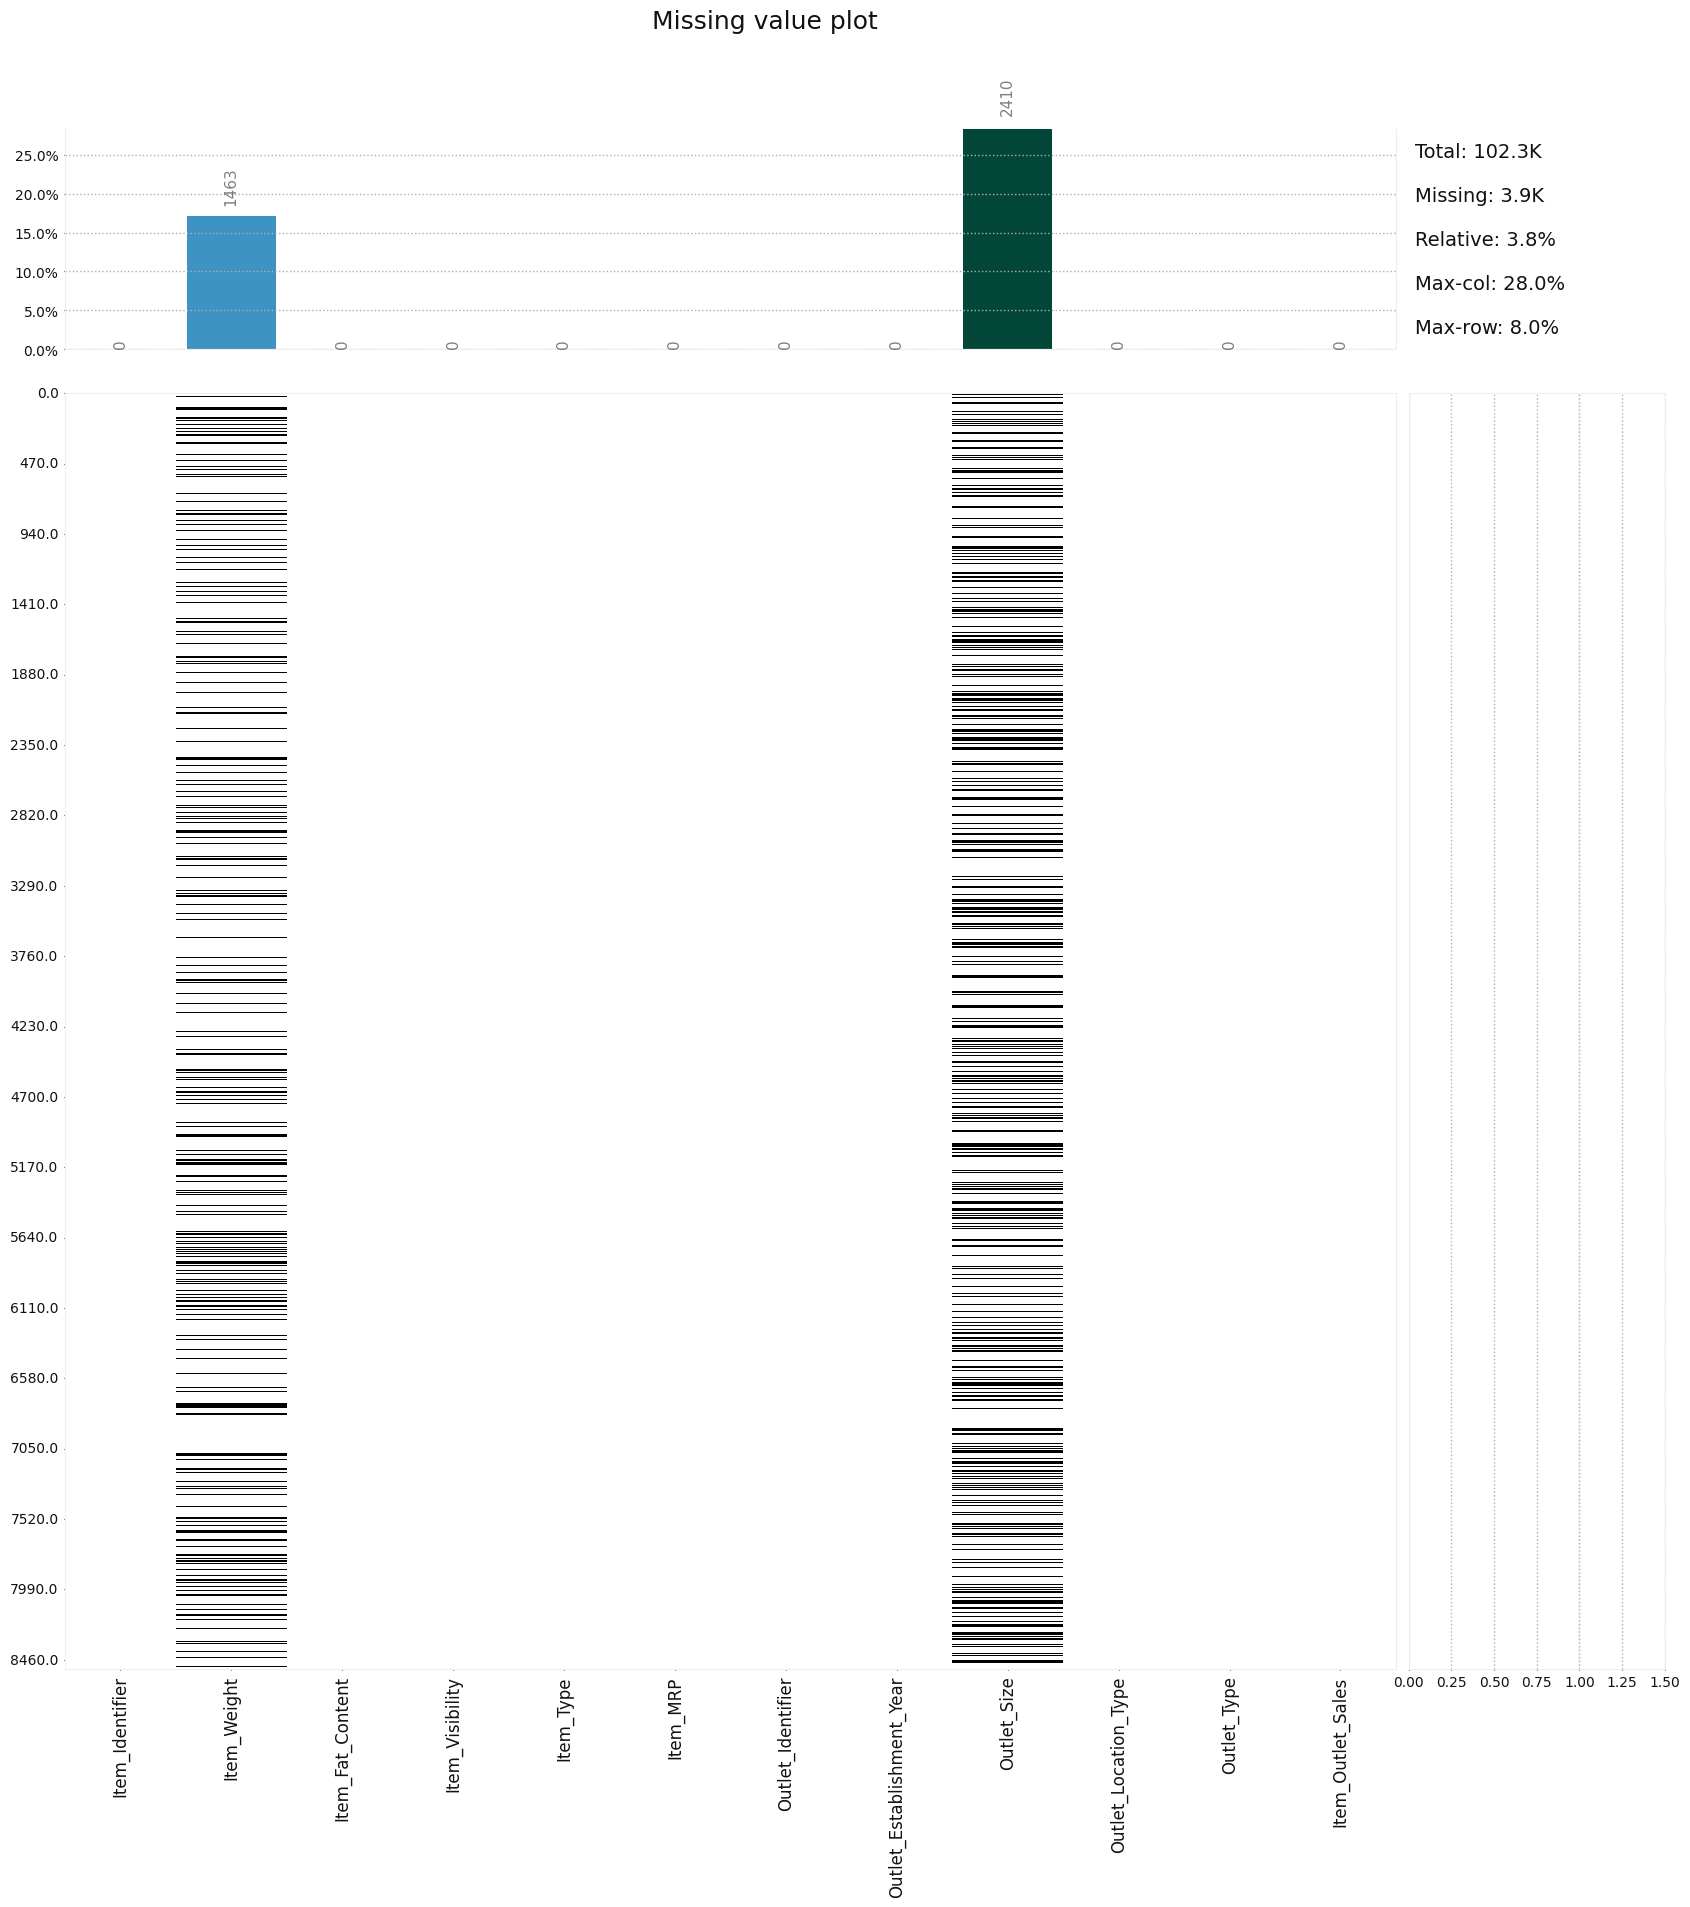

In [3]:
klib.missingval_plot(df)  # seeing viually on missing values

In [194]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [4]:
from datacleaner import autoclean

df = autoclean(df)

/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/datacleaner/datacleaner.py:83: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  input_dataframe[column].fillna(input_dataframe[column].mode()[0], inplace=True)
/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [196]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


# Handl missing values

In [6]:
def tozala(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == 'str':
                df[col] = df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                df[col] = df[col].fillna(df[col].mean(), inplace=True)
    return df
tozala(df)

/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_1097/3475946427.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col] = df[col].fillna(df[col].mean(), inplace=True)
/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_1097/3475946427.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [8]:
klib.corr_interactive_plot(df, annot=True, figsize=(10,8))


ValueError: underlying array is read-only

In [9]:
df= klib.data_cleaning(df, drop_duplicates=True)

Shape of cleaned data: (8523, 12) - Remaining NAs: 0


Dropped rows: 0
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 0
Reduced memory by at least: 0.52 MB (-66.67%)



In [203]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   item_identifier            8523 non-null   string  
 1   item_weight                8523 non-null   float32 
 2   item_fat_content           8523 non-null   category
 3   item_visibility            8523 non-null   float32 
 4   item_type                  8523 non-null   category
 5   item_mrp                   8523 non-null   float32 
 6   outlet_identifier          8523 non-null   category
 7   outlet_establishment_year  8523 non-null   int16   
 8   outlet_size                8523 non-null   category
 9   outlet_location_type       8523 non-null   category
 10  outlet_type                8523 non-null   category
 11  item_outlet_sales          8523 non-null   float32 
dtypes: category(6), float32(4), int16(1), string(1)
memory usage: 266.8 KB


In [10]:
df.drop(['item_identifier', 'outlet_identifier'], axis=1)

,item_weight,item_fat_content,item_visibility,item_type,item_mrp,outlet_establishment_year,outlet_size,outlet_location_type,outlet_type,item_outlet_sales
0,9.300000,Low Fat,0.016047,Dairy,249.809204,1999,Medium,Tier 1,Supermarket Type1,3735.137939
1,5.920000,Regular,0.019278,Soft Drinks,48.269199,2009,Medium,Tier 3,Supermarket Type2,443.422791
2,17.500000,Low Fat,0.016760,Meat,141.617996,1999,Medium,Tier 1,Supermarket Type1,2097.270020
3,19.200001,Regular,0.000000,Fruits and Vegetables,182.095001,1998,Medium,Tier 3,Grocery Store,732.380005
4,8.930000,Low Fat,0.000000,Household,53.861401,1987,High,Tier 3,Supermarket Type1,994.705200
...,...,...,...,...,...,...,...,...,...,...
8518,6.865000,Low Fat,0.056783,Snack Foods,214.521805,1987,High,Tier 3,Supermarket Type1,2778.383301
8519,8.380000,Regular,0.046982,Baking Goods,108.156998,2002,Medium,Tier 2,Supermarket Type1,549.284973
8520,10.600000,Low Fat,0.035186,Health and Hygiene,85.122398,2004,Small,Tier 2,Supermarket Type1,1193.113647
8521,7.210000,Regular,0.145221,Snack Foods,103.133202,2009,Medium,Tier 3,Supermarket Type2,1845.597656


In [205]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   item_identifier            8523 non-null   string  
 1   item_weight                8523 non-null   float32 
 2   item_fat_content           8523 non-null   category
 3   item_visibility            8523 non-null   float32 
 4   item_type                  8523 non-null   category
 5   item_mrp                   8523 non-null   float32 
 6   outlet_identifier          8523 non-null   category
 7   outlet_establishment_year  8523 non-null   int16   
 8   outlet_size                8523 non-null   category
 9   outlet_location_type       8523 non-null   category
 10  outlet_type                8523 non-null   category
 11  item_outlet_sales          8523 non-null   float32 
dtypes: category(6), float32(4), int16(1), string(1)
memory usage: 266.8 KB


In [11]:
# Datacleaner--> missing datalarni handle qilib va encoding (LabelEncoder) qiladi. 
from datacleaner import autoclean
df = autoclean(df) 

/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/datacleaner/datacleaner.py:83: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  input_dataframe[column].fillna(input_dataframe[column].mode()[0], inplace=True)
/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/

In [12]:
df.head()

,item_identifier,item_weight,item_fat_content,item_visibility,item_type,item_mrp,outlet_identifier,outlet_establishment_year,outlet_size,outlet_location_type,outlet_type,item_outlet_sales
0,FDA15,9.300000,Low Fat,0.016047,Dairy,249.809204,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.137939
1,DRC01,5.920000,Regular,0.019278,Soft Drinks,48.269199,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.422791
2,FDN15,17.500000,Low Fat,0.016760,Meat,141.617996,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.270020
3,FDX07,19.200001,Regular,0.000000,Fruits and Vegetables,182.095001,OUT010,1998,Medium,Tier 3,Grocery Store,732.380005
4,NCD19,8.930000,Low Fat,0.000000,Household,53.861401,OUT013,1987,High,Tier 3,Supermarket Type1,994.705200


In [14]:
from sklearn.preprocessing import LabelEncoder

def encoding(df):
    le = LabelEncoder()
    for col in df.columns:
        if df[col].dtype == 'category' or df[col].dtype == 'string':
            df[col] = le.fit_transform(df[col])  # Encodingda inplace=True  parametri mavjud emas
    return df
df = encoding(df)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   item_identifier            8523 non-null   int64  
 1   item_weight                8523 non-null   float32
 2   item_fat_content           8523 non-null   int64  
 3   item_visibility            8523 non-null   float32
 4   item_type                  8523 non-null   int64  
 5   item_mrp                   8523 non-null   float32
 6   outlet_identifier          8523 non-null   int64  
 7   outlet_establishment_year  8523 non-null   int16  
 8   outlet_size                8523 non-null   int64  
 9   outlet_location_type       8523 non-null   int64  
 10  outlet_type                8523 non-null   int64  
 11  item_outlet_sales          8523 non-null   float32
dtypes: float32(4), int16(1), int64(7)
memory usage: 616.0 KB


In [16]:
df.head()

,item_identifier,item_weight,item_fat_content,item_visibility,item_type,item_mrp,outlet_identifier,outlet_establishment_year,outlet_size,outlet_location_type,outlet_type,item_outlet_sales
0,156,9.300000,1,0.016047,4,249.809204,9,1999,1,0,1,3735.137939
1,8,5.920000,2,0.019278,14,48.269199,3,2009,1,2,2,443.422791
2,662,17.500000,1,0.016760,10,141.617996,9,1999,1,0,1,2097.270020
3,1121,19.200001,2,0.000000,6,182.095001,0,1998,1,2,0,732.380005
4,1297,8.930000,1,0.000000,9,53.861401,1,1987,0,2,1,994.705200


In [17]:
# Model Selection
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR

In [18]:
lr = LogisticRegression()
lg = LinearRegression()
dt_class = DecisionTreeClassifier()
dt_reg = DecisionTreeRegressor()
rf_class = RandomForestClassifier()
rf_reg = RandomForestRegressor()
svc = SVC(kernel='linear', C=1.0)
svr = SVR(kernel='linear', C=1.0)

# Klib with Logistic Regression

In [38]:
x = df.drop(['outlet_size', 'item_identifier', 'outlet_identifier'], axis=1)
y = df['outlet_size']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       188
           1       0.69      0.80      0.74      1035
           2       0.59      0.63      0.61       482

    accuracy                           0.66      1705
   macro avg       0.43      0.47      0.45      1705
weighted avg       0.59      0.66      0.62      1705



/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Us

# Linear Regression 

In [40]:
x = df.drop(['item_outlet_sales', 'item_identifier', 'outlet_identifier'], axis=1)
y = df['item_outlet_sales']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

lg.fit(x_train, y_train)

y_pred = lg.predict(x_test)

In [41]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.5242478601114535
856.4053568319722
1293080.076273252


# Decision Tree Classifier

In [24]:
x = df.drop(['outlet_size', 'item_identifier', 'outlet_identifier'], axis=1)
y = df['outlet_size']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

dt_class.fit(x_train, y_train)

y_pred = dt_class.predict(x_test)

In [25]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       188
           1       1.00      1.00      1.00      1035
           2       1.00      1.00      1.00       482

    accuracy                           1.00      1705
   macro avg       1.00      1.00      1.00      1705
weighted avg       1.00      1.00      1.00      1705



# Decision Tree Regressor 

In [26]:
x = df.drop(['item_outlet_sales', 'item_identifier', 'outlet_identifier'], axis=1)
y = df['item_outlet_sales']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

dt_reg.fit(x_train, y_train)

y_pred = dt_reg.predict(x_test)

In [27]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.19220882287937002
1026.4222751628618
2195552.2410654975


# Random Forest Classifier

In [28]:
x = df.drop(['outlet_size', 'item_identifier', 'outlet_identifier'], axis=1)
y = df['outlet_size']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

rf_class.fit(x_train, y_train)

y_pred = rf_class.predict(x_test)

In [29]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       188
           1       1.00      1.00      1.00      1035
           2       1.00      1.00      1.00       482

    accuracy                           1.00      1705
   macro avg       1.00      1.00      1.00      1705
weighted avg       1.00      1.00      1.00      1705



# Random Forest Regressor 

In [30]:
x = df.drop(['item_outlet_sales', 'item_identifier', 'outlet_identifier'], axis=1)
y = df['item_outlet_sales']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

rf_reg.fit(x_train, y_train)

y_pred = rf_reg.predict(x_test)

In [31]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.5644912228910794
758.192494257102
1183699.8207797892


# Support Vector Machine Classifier

In [33]:
x = df.drop(['outlet_size', 'item_identifier', 'outlet_identifier'], axis=1)
y = df['outlet_size']

# Model train_test_split process
from sklearn.model_selection import train_test_split
svc = SVC(kernel='linear', C=1.0, max_iter=2000)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


svc.fit(x_train, y_train)

y_pred = svc.predict(x_test)

/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [34]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.16      0.59      0.26       188
           1       0.70      0.41      0.52      1035
           2       0.45      0.38      0.41       482

    accuracy                           0.42      1705
   macro avg       0.44      0.46      0.40      1705
weighted avg       0.57      0.42      0.46      1705



# Support Vector Machine Regressor 

In [35]:
x = df.drop(['item_outlet_sales', 'item_identifier', 'outlet_identifier'], axis=1)
y = df['item_outlet_sales']

# Model train_test_split process
from sklearn.model_selection import train_test_split
svc = SVC(kernel='linear', C=1.0, max_iter=2000)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

svr.fit(x_train, y_train)

y_pred = svr.predict(x_test)

In [36]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.4853575440328727
869.4653868275694
1398782.7913319026


In [42]:
from tabulate import tabulate
results_class = [
    ['Logistic Regression', 0.66,0.69,0.80,0.74],
    ['Decison Tree Classifier', 1.00,1.00 ,01.00,1.00],
    ['Random Forest Classifier', 1.00, 1.00, 1.00,1.00],
    ['Support Vector Classifier', 0.42, 0.70, 0.41,0.52]
]

results_reg = [
    ['Linear Regressor', 0.52, 856.90, 1293080.07],
    ['Decison Tree Regressor', 0.19, 1026.42, 2195552.24],
    ['Random Forest Regressor', 0.56, 758.19, 1183699.82],
    ['Support Vector Regressor', 0.48, 869.46, 1398782.79]
]

headers_class = ['Algorithms', 'Accuracy', 'Precision', 'Recall', 'f1_score']
table_class = tabulate(results_class, headers=headers_class, tablefmt='grid', floatfmt='.2f')
print(table_class)

print('---------------------------------------------------------------------------------')
print('##################################################################################')
print('---------------------------------------------------------------------------------')

headers_reg = ['Algorithms', 'r2_score', 'mean_absolute_error', 'mean_squared_error']
table_reg = tabulate(results_reg, headers=headers_reg, tablefmt='grid', floatfmt='.2f')
print(table_reg)

+---------------------------+------------+-------------+----------+------------+
| Algorithms                |   Accuracy |   Precision |   Recall |   f1_score |
+===========================+============+=============+==========+============+
| Logistic Regression       |       0.66 |        0.69 |     0.80 |       0.74 |
+---------------------------+------------+-------------+----------+------------+
| Decison Tree Classifier   |       1.00 |        1.00 |     1.00 |       1.00 |
+---------------------------+------------+-------------+----------+------------+
| Random Forest Classifier  |       1.00 |        1.00 |     1.00 |       1.00 |
+---------------------------+------------+-------------+----------+------------+
| Support Vector Classifier |       0.42 |        0.70 |     0.41 |       0.52 |
+---------------------------+------------+-------------+----------+------------+
---------------------------------------------------------------------------------
###########################

In [43]:
# Eng yaxshi Classifier va eng yaxshi Regressor Algoritmini topish  Klib orqali qilinganda

eng_yaxshi = max(model[1] for model in results_class)  # bu maksimum qiymatlarni oladi
yaxshi_modellar = []  # yangi list shu yerga yig'amiz eng kattalarini

for model in results_class:
    # Shu yerda agar model[1] eng yaxshiga va model[0] ikkisini ichida bo'lsa 
    if model[1] == eng_yaxshi and model[0] in ['Decison Tree Classifier', 'Random Forest Classifier']:  
        # bizga yaxshi_model listimizga qo'shib ber 
        yaxshi_modellar.append(model)

for model in yaxshi_modellar:
    print(f'Eng yaxshi model: {model[0]}, eng yaxshi metrik esa: {model[1]}')


Eng yaxshi model: Decison Tree Classifier, eng yaxshi metrik esa: 1.0
Eng yaxshi model: Random Forest Classifier, eng yaxshi metrik esa: 1.0


In [48]:
best_model_reg = results_reg[0]

for model_reg in results_reg:
    if model_reg[2] < best_model_reg[2]:
        best_model_reg = model_reg
print(f"Eng yaxshi model Regressor uchun: ", best_model_reg[0])
print(f"Eng yaxshi MAE qiymati: ", best_model_reg[2])

Eng yaxshi model Regressor uchun:  Random Forest Regressor
Eng yaxshi MAE qiymati:  758.19


# Deyarli katta farq qilmadi, mae da oldingisida klibsiz: 757.07 bo'lsa bunda esa klib bilan esa 758.19 yani 1 ga farq qildi. Ammmo Classificationda o'sha-o'sha DTC va RFCda 1.0dan chiqdi.